# Lab 08 — LoRA Fine-Tuning

**Goal:** repeat the Lab 07 supervised fine-tuning experiment using LoRA instead of updating all ~596M Qwen parameters.

Lab 07 taught us what full fine-tuning looks like:

```text
trainable parameters: ~596M
validation loss:      8.55 → 0.675
overall exact acc:    65.1%
VALID_CANDIDATE:      79.8%
CHOOSE_VALID:         76.7%
NEXT_GUESS:            1.8%
game solve rate:       5%
```

Lab 08 asks a different question:

> How much of that adaptation can we recover while training only a tiny fraction of the model?

We are not trying to fix the Wordle policy in this lab. We are learning **parameter-efficient fine-tuning**.

## 8.1 What LoRA changes

Full fine-tuning updates a weight matrix directly:

```text
W → W + ΔW
```

LoRA freezes `W` and learns a low-rank update:

```text
ΔW = B @ A
```

where:

```text
A: d_in × r
B: r × d_out
```

and `r` is much smaller than the original dimensions.

Instead of learning every element of a large projection matrix, LoRA learns two small matrices whose product modifies that projection.

The pretrained weights remain frozen.

That gives us:

- fewer trainable parameters;
- smaller optimizer state;
- smaller checkpoints;
- easy adapter swapping;
- often similar downstream adaptation quality.

Hugging Face PEFT implements this by inserting trainable low-rank adapters into selected transformer modules while freezing the base model.

## 8.2 Restart the kernel

Start from a clean Jupyter kernel.

Then make sure PEFT is installed in the environment:

```bash
pip install -U peft
```

You only need to do that once.

In [2]:
pip install -U peft

/Users/ianphil/src/tiny-wordle-lab-v2/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B"
MAX_LENGTH = 128
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("device:", device)
print("PyTorch:", torch.__version__)

device: mps
PyTorch: 2.13.0


## 8.3 Load the exact Lab 06 dataset

No dataset changes.

That is essential to the comparison.

In [2]:
DATA_DIR = Path("../data/generated")

dataset = load_dataset(
    "json",
    data_files={
        "train": str(DATA_DIR / "wordle-sft-train.jsonl"),
        "validation": str(DATA_DIR / "wordle-sft-dev.jsonl"),
        "test": str(DATA_DIR / "wordle-sft-test.jsonl"),
    },
)

assert dataset["train"].num_rows == 16465
assert dataset["validation"].num_rows == 2169
assert dataset["test"].num_rows == 190

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 16465
    })
    validation: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 2169
    })
    test: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 190
    })
})


## 8.4 Load the untouched base model

Do **not** initialize LoRA from the Lab 07 checkpoint.

We want:

```text
Qwen3-0.6B base → full SFT
```

versus:

```text
Qwen3-0.6B base → LoRA SFT
```

Same starting point. Different adaptation method.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32,
).to(device)

print(type(base_model).__name__)
print("total parameters:", f"{sum(p.numel() for p in base_model.parameters()):,}")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Qwen3ForCausalLM
total parameters: 596,049,920


## 8.5 Inspect Qwen's projection modules

LoRA attaches to named linear layers.

From Lab 01, Qwen3 attention contains:

```text
q_proj
k_proj
v_proj
o_proj
```

For the first LoRA experiment, we target those four attention projections in every transformer layer.

We deliberately do **not** target the MLP yet. Keep the first experiment easy to reason about.

In [4]:
target_names = set()

for name, module in base_model.named_modules():
    if any(
        name.endswith(x)
        for x in ["q_proj", "k_proj", "v_proj", "o_proj"]
    ):
        target_names.add(name.split(".")[-1])

print("LoRA target module names:", sorted(target_names))

LoRA target module names: ['k_proj', 'o_proj', 'q_proj', 'v_proj']


## 8.6 Configure LoRA

Our first configuration:

```text
rank r:          8
alpha:          16
dropout:        0.05
target modules: q/k/v/o attention projections
```

`r=8` means the learned update is constrained to rank 8.

`lora_alpha` scales the adapter contribution.

These are reasonable starter values, not sacred constants.

In [5]:
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
    bias="none",
)

model = get_peft_model(
    base_model,
    lora_config,
)

model.print_trainable_parameters()

trainable params: 2,293,760 || all params: 598,343,680 || trainable%: 0.3834


### Stop and compare

Lab 07:

```text
trainable ≈ 596,049,920
```

Lab 08 should show dramatically fewer trainable parameters.

Calculate:

```text
trainable LoRA parameters / total model parameters
```

That fraction is one of the main outputs of this lab.

In [6]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("total parameters:", f"{total_params:,}")
print("trainable parameters:", f"{trainable_params:,}")
print(
    "trainable fraction:",
    f"{100 * trainable_params / total_params:.4f}%"
)

total parameters: 598,343,680
trainable parameters: 2,293,760
trainable fraction: 0.3834%


## 8.7 Verify the base weights are frozen

Pick several ordinary base-model parameters and verify they do not require gradients.

In [7]:
checked = 0

for name, param in model.named_parameters():
    if "lora_" not in name:
        print(name, "requires_grad=", param.requires_grad)
        assert not param.requires_grad
        checked += 1

    if checked >= 5:
        break

print("Base-weight freeze check passed.")

base_model.model.model.embed_tokens.weight requires_grad= False
base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight requires_grad= False
base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight requires_grad= False
base_model.model.model.layers.0.self_attn.v_proj.base_layer.weight requires_grad= False
base_model.model.model.layers.0.self_attn.o_proj.base_layer.weight requires_grad= False
Base-weight freeze check passed.


## 8.8 Reuse the exact Lab 07 formatting

The model-facing data should be identical.

Only the trainable parameterization changes.

In [8]:
def render_prompt(prompt: str) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

def render_full_example(
    prompt: str,
    response: str,
) -> tuple[str, str]:
    prompt_text = render_prompt(prompt)
    full_text = (
        prompt_text
        + response
        + tokenizer.eos_token
    )
    return prompt_text, full_text

def encode_example(example: dict) -> dict:
    prompt_text, full_text = render_full_example(
        example["prompt"],
        example["response"],
    )

    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
    )["input_ids"]

    full_ids = tokenizer(
        full_text,
        add_special_tokens=False,
    )["input_ids"]

    if len(full_ids) >= MAX_LENGTH:
        raise ValueError(
            f"sequence length {len(full_ids)} "
            f"reached MAX_LENGTH={MAX_LENGTH}"
        )

    labels = (
        [-100] * len(prompt_ids)
        + full_ids[len(prompt_ids):]
    )

    assert len(labels) == len(full_ids)
    assert any(x != -100 for x in labels)

    return {
        "input_ids": full_ids,
        "labels": labels,
    }

## 8.9 Collator and loaders

Use the same batch sizes as Lab 07 so throughput comparisons mean something.

In [9]:
PAD_ID = tokenizer.pad_token_id
if PAD_ID is None:
    PAD_ID = tokenizer.eos_token_id

def collate_batch(rows):
    encoded = [
        encode_example(row)
        for row in rows
    ]

    max_len = max(
        len(x["input_ids"])
        for x in encoded
    )

    input_rows = []
    label_rows = []
    attention_rows = []

    for item in encoded:
        ids = item["input_ids"]
        labels = item["labels"]
        pad = max_len - len(ids)

        input_rows.append(
            ids + [PAD_ID] * pad
        )
        label_rows.append(
            labels + [-100] * pad
        )
        attention_rows.append(
            [1] * len(ids) + [0] * pad
        )

    return {
        "input_ids": torch.tensor(
            input_rows,
            dtype=torch.long,
        ),
        "labels": torch.tensor(
            label_rows,
            dtype=torch.long,
        ),
        "attention_mask": torch.tensor(
            attention_rows,
            dtype=torch.long,
        ),
    }

BATCH_SIZE = 16
VAL_BATCH_SIZE = 32

train_loader = DataLoader(
    dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(
    dataset["validation"],
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))

train batches: 1030
validation batches: 68


## 8.10 Baseline validation loss

Before training the adapters, this should be close to Lab 07's untouched-model validation loss.

LoRA starts with no learned adaptation, so behavior should initially match the base model.

In [11]:
@torch.no_grad()
def evaluate_loss(model, loader) -> float:
    model.eval()
    losses = []

    for batch in loader:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        outputs = model(**batch)

        losses.append(
            outputs.loss
            .detach()
            .float()
            .cpu()
            .item()
        )

    model.train()
    return float(np.mean(losses))

baseline_val_loss = evaluate_loss(
    model,
    val_loader,
)

print("baseline validation loss:", baseline_val_loss)

baseline validation loss: 8.550293193143958


## 8.11 Generation baseline

Again, behavior should initially resemble untouched Qwen.

In [12]:
def generate_response(
    prompt: str,
    max_new_tokens: int = 16,
) -> str:
    text = render_prompt(prompt)
    batch = tokenizer(
        text,
        return_tensors="pt",
    ).to(device)

    model.eval()

    with torch.no_grad():
        output = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    new = output[
        0,
        batch["input_ids"].shape[1]:,
    ]

    result = tokenizer.decode(
        new,
        skip_special_tokens=True,
    ).strip()

    model.train()
    return result

for task in [
    "VALID_CANDIDATE",
    "CHOOSE_VALID",
    "NEXT_GUESS",
]:
    row = next(
        x
        for x in dataset["validation"]
        if x["task"] == task
    )

    print("=" * 80)
    print("TASK:", task)
    print("TARGET:", row["response"])
    print("MODEL:", generate_response(row["prompt"]))

TASK: VALID_CANDIDATE
TARGET: VALID
MODEL: To determine whether the candidate "L E A F Y" could still be the
TASK: CHOOSE_VALID
TARGET: ATTIC
MODEL: The valid five-letter word consistent with all previous feedback is: **E R E
TASK: NEXT_GUESS
TARGET: ADORN
MODEL: Y E B B B


## 8.12 Optimizer

Only LoRA parameters have `requires_grad=True`, so AdamW will effectively update only the adapters.

We can use a higher learning rate than full SFT because we are optimizing a small randomly initialized adapter rather than directly perturbing every pretrained weight.

Start with:

```text
learning rate: 1e-4
```

In [13]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
EPOCHS = 1

optimizer = AdamW(
    (
        p
        for p in model.parameters()
        if p.requires_grad
    ),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = max(
    1,
    int(total_steps * 0.05),
)

def lr_multiplier(step: int) -> float:
    if step < warmup_steps:
        return (
            (step + 1)
            / warmup_steps
        )

    progress = (
        (step - warmup_steps)
        / max(
            1,
            total_steps - warmup_steps,
        )
    )

    return 0.5 * (
        1.0
        + math.cos(
            math.pi * progress
        )
    )

scheduler = (
    torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lr_multiplier,
    )
)

print("total steps:", total_steps)
print("warmup steps:", warmup_steps)

total steps: 1030
warmup steps: 51


## 8.13 One-batch gradient sanity check

In [14]:
batch = next(iter(train_loader))

batch = {
    key: value.to(device)
    for key, value in batch.items()
}

model.train()
optimizer.zero_grad(set_to_none=True)

outputs = model(**batch)
loss = outputs.loss
loss.backward()

grad_norm = torch.nn.utils.clip_grad_norm_(
    (
        p
        for p in model.parameters()
        if p.requires_grad
    ),
    max_norm=1.0,
)

print(
    "sanity loss:",
    loss.detach().float().cpu().item(),
)
print(
    "LoRA gradient norm before clipping:",
    float(grad_norm),
)

sanity loss: 9.484407424926758
LoRA gradient norm before clipping: 114.2205810546875


In [15]:
optimizer.zero_grad(set_to_none=True)

## 8.14 Train one epoch

This intentionally mirrors Lab 07.

The only meaningful changes are:

- LoRA adapters instead of all parameters;
- higher adapter learning rate;
- adapter checkpoint instead of full-model checkpoint.

In [16]:
CHECKPOINT_DIR = Path(
    "../checkpoints/qwen3-0.6b-wordle-lora"
)
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LOG_EVERY = 25
EVAL_EVERY = 200

history = []
best_val_loss = float("inf")
global_step = 0

start_time = time.perf_counter()

model.train()

for epoch in range(EPOCHS):
    for batch in train_loader:
        global_step += 1

        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()

        grad_norm = (
            torch.nn.utils.clip_grad_norm_(
                (
                    p
                    for p in model.parameters()
                    if p.requires_grad
                ),
                max_norm=1.0,
            )
        )

        optimizer.step()
        scheduler.step()

        loss_value = (
            loss
            .detach()
            .float()
            .cpu()
            .item()
        )

        lr = scheduler.get_last_lr()[0]

        history.append({
            "step": global_step,
            "train_loss": loss_value,
            "lr": lr,
            "grad_norm": float(grad_norm),
            "val_loss": None,
        })

        if (
            global_step == 1
            or global_step % LOG_EVERY == 0
        ):
            elapsed = (
                time.perf_counter()
                - start_time
            )

            print(
                f"step {global_step:4d}/{total_steps} | "
                f"loss {loss_value:.4f} | "
                f"lr {lr:.2e} | "
                f"grad {float(grad_norm):.3f} | "
                f"{elapsed:.1f}s"
            )

        should_eval = (
            global_step % EVAL_EVERY == 0
            or global_step == total_steps
        )

        if should_eval:
            val_loss = evaluate_loss(
                model,
                val_loader,
            )

            history[-1]["val_loss"] = val_loss

            print(
                f"  validation @ step "
                f"{global_step}: "
                f"{val_loss:.4f}"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss

                print(
                    "  new best validation loss; "
                    "saving LoRA adapter"
                )

                model.save_pretrained(
                    CHECKPOINT_DIR
                )
                tokenizer.save_pretrained(
                    CHECKPOINT_DIR
                )

            model.train()

elapsed = (
    time.perf_counter()
    - start_time
)

print()
print("training complete")
print("elapsed seconds:", elapsed)
print(
    "best validation loss:",
    best_val_loss,
)

step    1/1030 | loss 9.1017 | lr 3.92e-06 | grad 103.546 | 1.0s
step   25/1030 | loss 1.5369 | lr 5.10e-05 | grad 12.230 | 16.1s
step   50/1030 | loss 0.5056 | lr 1.00e-04 | grad 3.129 | 31.1s
step   75/1030 | loss 0.9198 | lr 9.99e-05 | grad 17.456 | 46.0s
step  100/1030 | loss 0.7092 | lr 9.94e-05 | grad 4.287 | 61.2s
step  125/1030 | loss 1.1743 | lr 9.86e-05 | grad 6.316 | 76.1s
step  150/1030 | loss 0.5186 | lr 9.75e-05 | grad 2.231 | 90.9s
step  175/1030 | loss 0.3583 | lr 9.61e-05 | grad 2.792 | 105.8s
step  200/1030 | loss 0.5769 | lr 9.44e-05 | grad 3.062 | 120.7s
  validation @ step 200: 0.8910
  new best validation loss; saving LoRA adapter
step  225/1030 | loss 0.6628 | lr 9.24e-05 | grad 4.448 | 162.2s
step  250/1030 | loss 0.7312 | lr 9.01e-05 | grad 2.966 | 177.5s
step  275/1030 | loss 1.0769 | lr 8.76e-05 | grad 8.139 | 192.8s
step  300/1030 | loss 0.7294 | lr 8.49e-05 | grad 6.616 | 207.6s
step  325/1030 | loss 0.6182 | lr 8.19e-05 | grad 3.195 | 222.4s
step  350/1030

## 8.15 Plot LoRA training

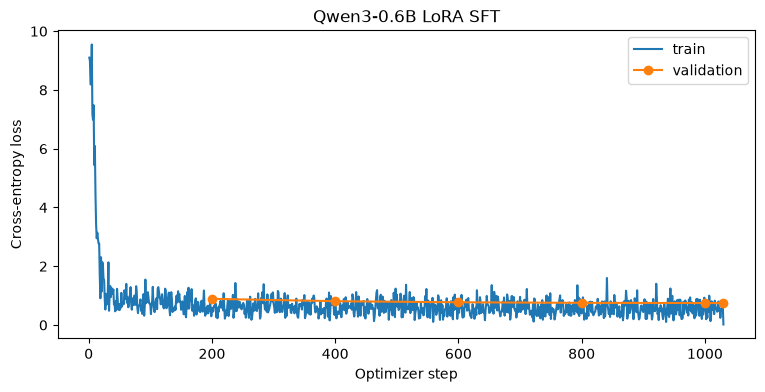

In [17]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 4))

plt.plot(
    history_df["step"],
    history_df["train_loss"],
    label="train",
)

val_points = history_df.dropna(
    subset=["val_loss"]
)

plt.plot(
    val_points["step"],
    val_points["val_loss"],
    marker="o",
    label="validation",
)

plt.xlabel("Optimizer step")
plt.ylabel("Cross-entropy loss")
plt.title("Qwen3-0.6B LoRA SFT")
plt.legend()
plt.show()

## 8.16 Compare adapter checkpoint size

Full SFT saved essentially another complete Qwen model.

LoRA should save only the small adapter weights plus configuration/tokenizer files.

In [18]:
def directory_size_mb(path: Path) -> float:
    return (
        sum(
            p.stat().st_size
            for p in path.rglob("*")
            if p.is_file()
        )
        / 1024**2
    )

print(
    "LoRA checkpoint size:",
    f"{directory_size_mb(CHECKPOINT_DIR):.2f} MiB",
)

full_sft_dir = Path(
    "../checkpoints/"
    "qwen3-0.6b-wordle-full-sft"
)

if full_sft_dir.exists():
    print(
        "Full SFT checkpoint size:",
        f"{directory_size_mb(full_sft_dir):.2f} MiB",
    )

LoRA checkpoint size: 19.68 MiB
Full SFT checkpoint size: 2284.68 MiB


## 8.17 Reload the best adapter

A LoRA checkpoint does not contain the entire base model.

Reloading is therefore:

```text
load base Qwen
      +
load adapter
```

In [19]:
del model

if device.type == "mps":
    torch.mps.empty_cache()

base_model = (
    AutoModelForCausalLM
    .from_pretrained(
        MODEL_ID,
        dtype=torch.float32,
    )
    .to(device)
)

model = PeftModel.from_pretrained(
    base_model,
    CHECKPOINT_DIR,
).to(device)

model.eval()

print("LoRA adapter reloaded.")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

LoRA adapter reloaded.


## 8.18 Final validation loss

In [20]:
final_val_loss = evaluate_loss(
    model,
    val_loader,
)

print(
    "baseline validation loss:",
    baseline_val_loss,
)
print(
    "LoRA validation loss:",
    final_val_loss,
)
print(
    "relative reduction:",
    f"{1 - final_val_loss / baseline_val_loss:.1%}",
)

baseline validation loss: 8.550293193143958
LoRA validation loss: 0.7484302840688649
relative reduction: 91.2%


## 8.19 Exact validation accuracy

In [21]:
def normalize_response(text: str) -> str:
    return (
        text
        .strip()
        .splitlines()[0]
        .strip()
        .upper()
    )

def evaluate_exact_accuracy(
    split,
):
    records = []

    for i, row in enumerate(split):
        generated = generate_response(
            row["prompt"],
            max_new_tokens=16,
        )

        actual = normalize_response(
            generated
        )

        expected = (
            row["response"]
            .strip()
            .upper()
        )

        records.append({
            "task": row["task"],
            "expected": expected,
            "actual": actual,
            "correct": actual == expected,
        })

        if (i + 1) % 250 == 0:
            print(
                f"{i + 1}/{len(split)}"
            )

    return pd.DataFrame(records)

val_predictions = (
    evaluate_exact_accuracy(
        dataset["validation"]
    )
)

print()
print("OVERALL")
print(
    f"{val_predictions['correct'].mean():.1%}"
)

print()
print("BY TASK")
print(
    val_predictions
    .groupby("task")["correct"]
    .mean()
    .sort_values(
        ascending=False
    )
)

250/2169
500/2169
750/2169
1000/2169
1250/2169
1500/2169
1750/2169
2000/2169

OVERALL
61.9%

BY TASK
task
VALID_CANDIDATE    0.763113
CHOOSE_VALID       0.719269
NEXT_GUESS         0.020779
Name: correct, dtype: float64


## 8.20 Compare Lab 07 vs Lab 08

| Metric | Full SFT | LoRA |
|---|---:|---:|
| Trainable params | 596,049,920 | 2,293,760 |
| Trainable fraction | 100% | 0.3834% |
| Training time | 1946.2 s | 785.5 s |
| Best val loss | 0.6751 | 0.7484 |
| Val loss reduction | 92.1% | 91.2% |
| Overall exact acc | 65.1% | 61.9% |
| VALID_CANDIDATE | 79.8% | 76.3% |
| CHOOSE_VALID | 76.7% | 71.9% |
| NEXT_GUESS | 1.8% | 2.1% |
| Checkpoint size | 2284.68 MiB | 19.68 MiB |

### Takeaway

LoRA recovered most of the full-SFT adaptation while training only **0.3834% of the model parameters**.

Compared with full SFT, LoRA:

- trained about **2.5× faster**;
- produced a checkpoint about **116× smaller**;
- achieved nearly the same validation-loss reduction: **91.2% vs 92.1%**;
- lost only **3.2 percentage points** of overall exact accuracy.

Full SFT still achieved the better final validation loss and higher accuracy on the two learned tasks, showing the additional adaptation capacity available when all model weights can change.

Both approaches performed essentially identically poorly on `NEXT_GUESS` (~2%), suggesting that this limitation comes primarily from the training objective/data rather than from LoRA's reduced parameter capacity.

For this experiment, LoRA therefore provided most of the useful supervised adaptation at a small fraction of the training and storage cost.

## 8.21 Optional: merge the adapter

PEFT can merge the learned low-rank update into the base weights:

```text
base weights + LoRA update
        ↓
ordinary standalone model
```

This is useful when you no longer need adapter swapping.

In [22]:
MERGED_DIR = Path(
    "../checkpoints/"
    "qwen3-0.6b-wordle-lora-merged"
)

merged_model = (
    model.merge_and_unload()
)

merged_model.save_pretrained(
    MERGED_DIR,
    safe_serialization=True,
)

tokenizer.save_pretrained(
    MERGED_DIR,
)

print("merged model saved:", MERGED_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

merged model saved: ../checkpoints/qwen3-0.6b-wordle-lora-merged


## 8.22 Rerun the Lab 04 benchmark

Use the **same frozen gameplay benchmark** as before.

For the easiest comparison, point Lab 04 at the merged model:

```python
MODEL_ID = (
    "../checkpoints/"
    "qwen3-0.6b-wordle-lora-merged"
)
```

Do not change the benchmark prompt, parser, answer set, or decoding.

Record:

```text
solve rate
history consistency
repeat guesses
valid output rate
```

We already know the static curriculum has poor gameplay transfer. That is fine.

The purpose here is to compare LoRA with full SFT under the same training objective.

# Lab 08 checkpoint

Send me these results:

1. LoRA trainable parameter count and percentage;
2. baseline validation loss;
3. pre-training generations;
4. one-batch sanity loss + gradient norm;
5. training time;
6. validation-loss checkpoints;
7. best LoRA validation loss;
8. exact accuracy overall and by task;
9. LoRA checkpoint size;
10. optional merged-model Lab 04 benchmark.

The key question is:

> How much adaptation did we get per trainable parameter compared with full SFT?

After that, we move on to **distillation**.